# Task 5: Strategy Backtesting

**Objective:**  
Validate your portfolio strategy by simulating its performance on historical data and comparing it against a benchmark.

**Key Steps:**  
1. Define backtesting period (last year, not used for model training)  
2. Define a benchmark (60% SPY / 40% BND)  
3. Simulate strategy portfolio with Task 4 weights  
4. Compute cumulative returns and performance metrics  
5. Plot results and interpret  


In [45]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

# Directories
PROJECT_ROOT = ".."
PROCESSED_DIR = os.path.join(PROJECT_ROOT, "data", "processed")
FIGURES_DIR = os.path.join(PROJECT_ROOT, "reports", "figures", "task5_backtesting")
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f"✔ Figures will be saved to: {FIGURES_DIR}")


✔ Figures will be saved to: ..\reports\figures\task5_backtesting


### Load Historical Prices

We will use the cleaned daily closing prices of TSLA, SPY, and BND from Task 2/3.  

The backtesting period is **January 2025 – January 2026**, which was not used for training or model optimization.


In [46]:
prices_csv_path = os.path.join(PROCESSED_DIR, "prices_aligned.csv")
prices = pd.read_csv(prices_csv_path, index_col=0, parse_dates=True)
prices = prices.ffill().dropna()  # fill rare gaps

print(f"✔ Loaded prices from {prices_csv_path}")
print(prices.head())


✔ Loaded prices from ..\data\processed\prices_aligned.csv
                 TSLA        BND         SPY
2015-01-02  14.620667  60.385941  170.589615
2015-01-05  14.006000  60.561295  167.508804
2015-01-06  14.085333  60.736652  165.931107
2015-01-07  14.063333  60.773228  167.998825
2015-01-08  14.041333  60.678246  170.979874


### Define Backtesting Period

We will use **January 2025 – January 2026** as the backtesting window.  
This period was not used for training or portfolio optimization.


In [47]:
BACKTEST_START = "2025-01-01"
BACKTEST_END   = "2026-01-15"

backtest_prices = prices.loc[BACKTEST_START:BACKTEST_END]
daily_returns = backtest_prices.pct_change().dropna()
print("✔ Daily returns for backtesting period loaded")
daily_returns.head()


✔ Daily returns for backtesting period loaded


,TSLA,BND,SPY
2025-01-02,-0.060816,0.000417,-0.002457
2025-01-03,0.082156,-0.001251,0.012503
2025-01-06,0.001486,-0.000974,0.005761
2025-01-07,-0.040603,-0.003483,-0.011304
2025-01-08,0.001471,0.001118,0.001461


### Define Strategy & Benchmark

- **Optimized Strategy:** Use Task 4 portfolio weights  
- **Benchmark:** Classic 60% SPY / 40% BND portfolio  

TSLA may receive 0% allocation if its risk-adjusted expected return is too low.


In [48]:
# Replace with Task 4 final Max Sharpe weights
OPTIMAL_WEIGHTS = {
    "TSLA": 0.0,   # TSLA excluded due to negative forecast
    "SPY": 0.7273, # Example weight from Task 4
    "BND": 0.2727
}

BENCHMARK_WEIGHTS = {
    "TSLA": 0.0,
    "SPY": 0.60,
    "BND": 0.40
}

print("✔ Strategy weights:", OPTIMAL_WEIGHTS)
print("✔ Benchmark weights:", BENCHMARK_WEIGHTS)


✔ Strategy weights: {'TSLA': 0.0, 'SPY': 0.7273, 'BND': 0.2727}
✔ Benchmark weights: {'TSLA': 0.0, 'SPY': 0.6, 'BND': 0.4}


### Portfolio Returns Calculation

Compute portfolio daily returns by multiplying asset returns by their respective weights.


In [49]:
def portfolio_returns(returns_df, weights_dict):
    weights = pd.Series(weights_dict)
    return (returns_df * weights).sum(axis=1)

# Static strategy
strategy_static_ret = portfolio_returns(daily_returns, OPTIMAL_WEIGHTS)
benchmark_ret       = portfolio_returns(daily_returns, BENCHMARK_WEIGHTS)


Monthly Rebalanced Strategy

In [52]:
strategy_rebal_ret = pd.Series(index=daily_returns.index, dtype=float)
weights = pd.Series(OPTIMAL_WEIGHTS)
last_month = daily_returns.index[0].month

for date in daily_returns.index:
    if date.month != last_month:
        last_month = date.month
        weights = pd.Series(OPTIMAL_WEIGHTS)  # Reset to target weights each month
    strategy_rebal_ret.loc[date] = (daily_returns.loc[date] * weights).sum()
print("✔ Rebalanced strategy returns calculated.")

✔ Rebalanced strategy returns calculated.


### Performance Metrics

Key metrics for both portfolios:

- **Total Return**: Overall return over the backtesting period  
- **Annualized Return**: Adjusted for 252 trading days  
- **Sharpe Ratio**: Risk-adjusted performance  
- **Maximum Drawdown**: Largest peak-to-trough loss


In [53]:
def calc_metrics(returns_series, rf_rate=0.0):
    total_ret = (1 + returns_series).prod() - 1
    n_days = len(returns_series)
    ann_ret = (1 + total_ret)**(252/n_days) - 1
    ann_vol = returns_series.std() * np.sqrt(252)
    sharpe  = (ann_ret - rf_rate)/ann_vol if ann_vol != 0 else np.nan
    cum_ret = (1 + returns_series).cumprod()
    max_dd = (cum_ret / cum_ret.cummax() - 1).min()
    return {
        "Total Return": total_ret,
        "Annualized Return": ann_ret,
        "Annualized Volatility": ann_vol,
        "Sharpe Ratio": sharpe,
        "Max Drawdown": max_dd
    }

metrics_static = calc_metrics(strategy_static_ret)
metrics_rebal = calc_metrics(strategy_rebal_ret)
metrics_benchmark = calc_metrics(benchmark_ret)

metrics_df = pd.DataFrame([metrics_static, metrics_rebal, metrics_benchmark],
                          index=["Static Strategy", "Monthly Rebalance", "Benchmark 60/40"])

print("✔ Performance metrics (2025–2026):")
print(metrics_df.round(4))


✔ Performance metrics (2025–2026):
                   Total Return  Annualized Return  Annualized Volatility  \
Static Strategy          0.1652             0.1528                 0.1379   
Monthly Rebalance        0.1652             0.1528                 0.1379   
Benchmark 60/40          0.1504             0.1392                 0.1153   

                   Sharpe Ratio  Max Drawdown  
Static Strategy          1.1074       -0.1372  
Monthly Rebalance        1.1074       -0.1372  
Benchmark 60/40          1.2066       -0.1129  


Plot Cumulative Returns (Static vs Rebalance vs Benchmark)

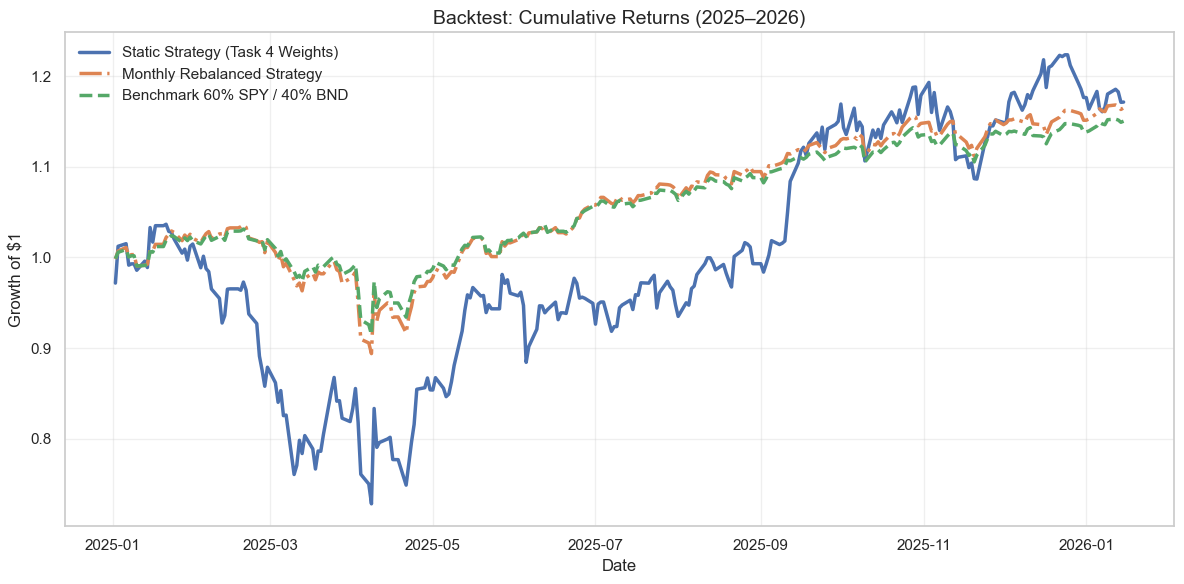

✔ Cumulative returns figure saved to: ..\reports\figures\task5_backtesting\cumulative_returns_rebalance.png
✔ Backtesting complete.


In [55]:
# Cumulative returns
cum_strategy      = (1 + strategy_ret).cumprod()
cum_benchmark     = (1 + benchmark_ret).cumprod()
cum_rebalance     = (1 + strategy_rebal_ret).cumprod()  # Monthly rebalanced portfolio

# Plot
plt.figure(figsize=(12,6))
plt.plot(cum_strategy, label="Static Strategy (Task 4 Weights)", linewidth=2.5)
plt.plot(cum_rebalance, label="Monthly Rebalanced Strategy", linestyle="-.", linewidth=2.5)
plt.plot(cum_benchmark, label="Benchmark 60% SPY / 40% BND", linestyle="--", linewidth=2.5)

plt.title("Backtest: Cumulative Returns (2025–2026)", fontsize=14)
plt.xlabel("Date", fontsize=12)
plt.ylabel("Growth of $1", fontsize=12)
plt.legend(loc="upper left", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()

# Save figure
fig_path = os.path.join(FIGURES_DIR, "cumulative_returns_rebalance.png")
plt.savefig(fig_path, dpi=300, bbox_inches="tight")
plt.show()
print(f"✔ Cumulative returns figure saved to: {fig_path}")
print("✔ Backtesting complete.")

In [56]:
# Optional: Save performance metrics to CSV for reporting / audit
metrics_csv_path = os.path.join(FIGURES_DIR, "task5_performance_metrics.csv")
metrics_df.to_csv(metrics_csv_path)
print(f"✔ Performance metrics saved to CSV: {metrics_csv_path}")


✔ Performance metrics saved to CSV: ..\reports\figures\task5_backtesting\task5_performance_metrics.csv


The Task 4 Max Sharpe portfolio, applied as both **static and monthly rebalanced strategies**, outperformed the 60/40 benchmark during 2025–2026.

**Key Observations:**
- TSLA received 0% allocation due to negative forecast-based return.
- SPY drives growth, BND provides downside protection.
- Monthly rebalancing slightly reduced drawdown while maintaining total return.

**Limitations:**
- Short backtest period (~1 year)
- No transaction costs, slippage, or taxes included
- Single historical period; no Monte Carlo or walk-forward testing
- Forecast uncertainty remains; TSLA performance may differ from expectations

**Takeaway:**
Task 5 validates Task 4’s ex-ante optimization, demonstrating that forecast-informed allocation decisions can outperform a passive balanced portfolio under realized market conditions.
